In [1]:
from datetime import datetime

print("Last run:", datetime.now().strftime("%d.%m.%Y %H:%M:%S"))

Last run: 09.03.2026 10:51:19


# Dense vs Sparse Benchmark for `XXXX_p2143`

This notebook compares the dense and sparse observable/Hamiltonian implementations at cutoff $\Lambda = 20$ for the operator `XXXX_p2143`.

For each storage method it:

1. builds the observable in memory without saving it,
2. assembles the corresponding Hamiltonian object,
3. evaluates the first eigenvalue for several couplings,
4. compares runtimes and approximate memory footprints.

The timed observable build uses the internal woven-to-observable builder directly so that saved observable files do not hide the real assembly cost. If prerequisite woven or coset data are missing, the setup cell below will generate them once outside the benchmark timings.

In [2]:
import sys
import time
from dataclasses import fields, is_dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse
from scipy.sparse import linalg as spla

from sym_contractions import (
    CHARACTER_TABLE_DIR,
    DATA_ROOT,
    HamiltonianDense,
    HamiltonianSparse,
    build_observables,
)
from sym_contractions.hamiltonian import (
    ObservableDense,
    ObservableSparse,
    _build_observable_from_woven,
    _label_to_woven_filename,
)
from sym_contractions.woven import load_woven_json

## Benchmark configuration

The observable is built from the precomputed woven data for mass $m = 1/2$, then the Hamiltonian is evaluated at fixed mass and dimension for a range of couplings.

The coupling is chosen exactly as in the demo pattern:

$$
g(d, m) = \frac{m^2 g_0}{d}
$$

with $g_0$ scanned over a fixed grid.

In [3]:
LABEL = "XXXX_p2143"
LAMBDA = 20
REFERENCE_MASS = 0.5
EVAL_MASS = 2.0
DIM = 10
GROUND_STATE_ONLY = True
COUPLINGS = np.linspace(0.0, 4.0, 9)

WOVEN_PATH = (
    DATA_ROOT
    / "woven_contractions"
    / _label_to_woven_filename(LABEL, REFERENCE_MASS, LAMBDA)
)
COSET_PATH = DATA_ROOT / "coset_reps" / "coset_reps.json"

print(f"label            = {LABEL}")
print(f"Lambda           = {LAMBDA}")
print(f"reference mass   = {REFERENCE_MASS}")
print(f"evaluation mass  = {EVAL_MASS}")
print(f"dimension d      = {DIM}")
print(f"ground-state only= {GROUND_STATE_ONLY}")
print(f"couplings        = {COUPLINGS}")

label            = XXXX_p2143
Lambda           = 20
reference mass   = 0.5
evaluation mass  = 2.0
dimension d      = 10
ground-state only= True
couplings        = [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4. ]


In [4]:
def format_bytes(n_bytes: int | float) -> str:
    units = ["B", "KiB", "MiB", "GiB", "TiB"]
    value = float(n_bytes)
    for unit in units:
        if value < 1024.0 or unit == units[-1]:
            return f"{value:.2f} {unit}"
        value /= 1024.0


def deep_size(obj, seen=None) -> int:
    if seen is None:
        seen = set()

    obj_id = id(obj)
    if obj_id in seen:
        return 0
    seen.add(obj_id)

    if isinstance(obj, np.ndarray):
        return sys.getsizeof(obj) + obj.nbytes

    if sparse.issparse(obj):
        return (
            sys.getsizeof(obj)
            + obj.data.nbytes
            + obj.indices.nbytes
            + obj.indptr.nbytes
        )

    if is_dataclass(obj):
        size = sys.getsizeof(obj)
        for field in fields(obj):
            size += deep_size(getattr(obj, field.name), seen)
        return size

    if isinstance(obj, dict):
        size = sys.getsizeof(obj)
        for key, value in obj.items():
            size += deep_size(key, seen)
            size += deep_size(value, seen)
        return size

    if isinstance(obj, (list, tuple, set)):
        size = sys.getsizeof(obj)
        for item in obj:
            size += deep_size(item, seen)
        return size

    return sys.getsizeof(obj)


def observable_coeff_storage_bytes(obs) -> int:
    if obs.storage_kind == "dense":
        return int(obs.unnorm_coeffs.nbytes)
    return int(
        sum(
            coeff.data.nbytes + coeff.indices.nbytes + coeff.indptr.nbytes
            for coeff in obs.unnorm_coeffs
        )
    )


def first_eigenvalue(matrix) -> float:
    if sparse.issparse(matrix):
        eig0 = spla.eigsh(matrix, k=1, which="SA", return_eigenvectors=False)[0]
        return float(np.real(eig0))
    eig0 = np.linalg.eigvalsh(matrix)[0]
    return float(np.real(eig0))


def coupling_function_factory(g0: float):
    def coupling(d, m, _g0=g0):
        return m**2 * _g0 / d

    return coupling


def ensure_inputs_exist() -> None:
    if WOVEN_PATH.exists() and COSET_PATH.exists():
        print("Prerequisite woven/coset data already available.")
        return

    print("Generating prerequisite data once before benchmarking...")
    _ = build_observables(
        [LABEL],
        Lambda=LAMBDA,
        mass=REFERENCE_MASS,
        clean=False,
        verbose=True,
        save=False,
        storage="dense",
    )


def benchmark_storage(storage: str):
    if storage == "dense":
        observable_cls = ObservableDense
        hamiltonian_cls = HamiltonianDense
    elif storage == "sparse":
        observable_cls = ObservableSparse
        hamiltonian_cls = HamiltonianSparse
    else:
        raise ValueError("storage must be 'dense' or 'sparse'")

    woven = load_woven_json(WOVEN_PATH)

    t0 = time.perf_counter()
    obs = _build_observable_from_woven(
        woven,
        CHARACTER_TABLE_DIR,
        COSET_PATH,
        storage=storage,
        verbose=False,
    )
    observable_time = time.perf_counter() - t0
    assert isinstance(obs, observable_cls)

    t0 = time.perf_counter()
    ham = hamiltonian_cls(
        observables=[obs],
        Lambda=LAMBDA,
        default_mass=REFERENCE_MASS,
    )
    hamiltonian_time = time.perf_counter() - t0

    spectral_rows = []
    for g0 in COUPLINGS:
        coupling = coupling_function_factory(float(g0))

        t_eval = time.perf_counter()
        H = ham.evaluate(
            d=DIM,
            coupling=coupling,
            mass=EVAL_MASS,
            ground_state_only=GROUND_STATE_ONLY,
        )
        eval_time = time.perf_counter() - t_eval

        t_eig = time.perf_counter()
        eig0 = first_eigenvalue(H) / DIM**2
        eig_time = time.perf_counter() - t_eig

        spectral_rows.append(
            {
                "storage": storage,
                "g0": float(g0),
                "evaluate_s": eval_time,
                "eig_s": eig_time,
                "total_s": eval_time + eig_time,
                "eig0_over_d2": eig0,
                "matrix_shape": H.shape[0],
                "matrix_type": type(H).__name__,
            }
        )

    return {
        "storage": storage,
        "observable": obs,
        "hamiltonian": ham,
        "observable_time_s": observable_time,
        "hamiltonian_time_s": hamiltonian_time,
        "observable_storage_bytes": observable_coeff_storage_bytes(obs),
        "observable_total_bytes": deep_size(obs),
        "hamiltonian_total_bytes": deep_size(ham),
        "spectral": pd.DataFrame(spectral_rows),
    }

In [5]:
ensure_inputs_exist()
print(f"woven path exists: {WOVEN_PATH.exists()}")
print(f"coset path exists: {COSET_PATH.exists()}")

Generating prerequisite data once before benchmarking...
Running generate_data.sh with: --lambda 20 --ops XXXX:2143 --mass 0.5
Using gap-system command
generate_all.sh — PRODUCTION MODE
Parameters:
  Lambda      = 20
  Ops list    = XXXX:2143
  K max       = 4
  DC parity   = even
  DC offset   = 2
  mass        = 0.5
  nmax_ssct   = 0
  nmax_ct     = 20
  nmax_dc     = 24
  GAP output  = /Users/jcazalis/Projects/02_DESY/04_matrix-models/02_twobraner/data/processed/{character_tables,conjugacy_classes,double_cosets,coset_reps}
  Woven dir   = /Users/jcazalis/Projects/02_DESY/04_matrix-models/02_twobraner/data/processed/woven_contractions
  Coset JSON  = /Users/jcazalis/Projects/02_DESY/04_matrix-models/02_twobraner/data/processed/coset_reps/coset_reps.json

----------------------------------------------------------------------------
Step 1/6: Symmetric character tables + conjugacy classes (Mathematica format)
----------------------------------------------------------------------------
S

## Run the dense and sparse benchmarks

In [6]:
dense_result = benchmark_storage("dense")
sparse_result = benchmark_storage("sparse")

results = {"dense": dense_result, "sparse": sparse_result}
spectral_df = pd.concat(
    [dense_result["spectral"], sparse_result["spectral"]], ignore_index=True
)

summary_df = pd.DataFrame(
    [
        {
            "storage": result["storage"],
            "observable_build_s": result["observable_time_s"],
            "hamiltonian_init_s": result["hamiltonian_time_s"],
            "observable_coeff_storage": format_bytes(
                result["observable_storage_bytes"]
            ),
            "observable_total": format_bytes(result["observable_total_bytes"]),
            "hamiltonian_total": format_bytes(result["hamiltonian_total_bytes"]),
            "avg_eval_s": result["spectral"]["evaluate_s"].mean(),
            "avg_eig_s": result["spectral"]["eig_s"].mean(),
            "avg_total_s": result["spectral"]["total_s"].mean(),
        }
        for result in results.values()
    ]
)
summary_df

,storage,observable_build_s,hamiltonian_init_s,observable_coeff_storage,observable_total,hamiltonian_total,avg_eval_s,avg_eig_s,avg_total_s
0,dense,104.425871,0.002664,2.47 GiB,4.94 GiB,4.97 GiB,0.111698,0.131851,0.243549
1,sparse,99.219868,0.001487,13.53 MiB,13.81 MiB,14.38 MiB,0.001755,0.004926,0.006681


In [7]:
spectral_df

,storage,g0,evaluate_s,eig_s,total_s,eig0_over_d2,matrix_shape,matrix_type
0,dense,0.0,0.985731,0.094429,1.080160,1.000000,1368,ndarray
1,dense,0.5,0.002255,0.124810,0.127065,1.571919,1368,ndarray
2,dense,1.0,0.002735,0.195056,0.197791,1.929065,1368,ndarray
3,dense,1.5,0.003346,0.134558,0.137904,2.273298,1368,ndarray
4,dense,2.0,0.001737,0.100015,0.101752,2.614839,1368,ndarray
5,dense,2.5,0.002993,0.136850,0.139844,2.955392,1368,ndarray
6,dense,3.0,0.002777,0.128031,0.130808,3.295473,1368,ndarray
7,dense,3.5,0.001792,0.128808,0.130600,3.635292,1368,ndarray
8,dense,4.0,0.001912,0.144102,0.146014,3.974952,1368,ndarray
9,sparse,0.0,0.014646,0.003427,0.018073,1.000000,1368,csr_matrix


## Timing and memory comparison

The first panel compares one-off costs: observable construction and Hamiltonian assembly. The second and third panels compare repeated costs across the coupling scan. The final panel compares the normalized lowest eigenvalue to verify that dense and sparse agree numerically.

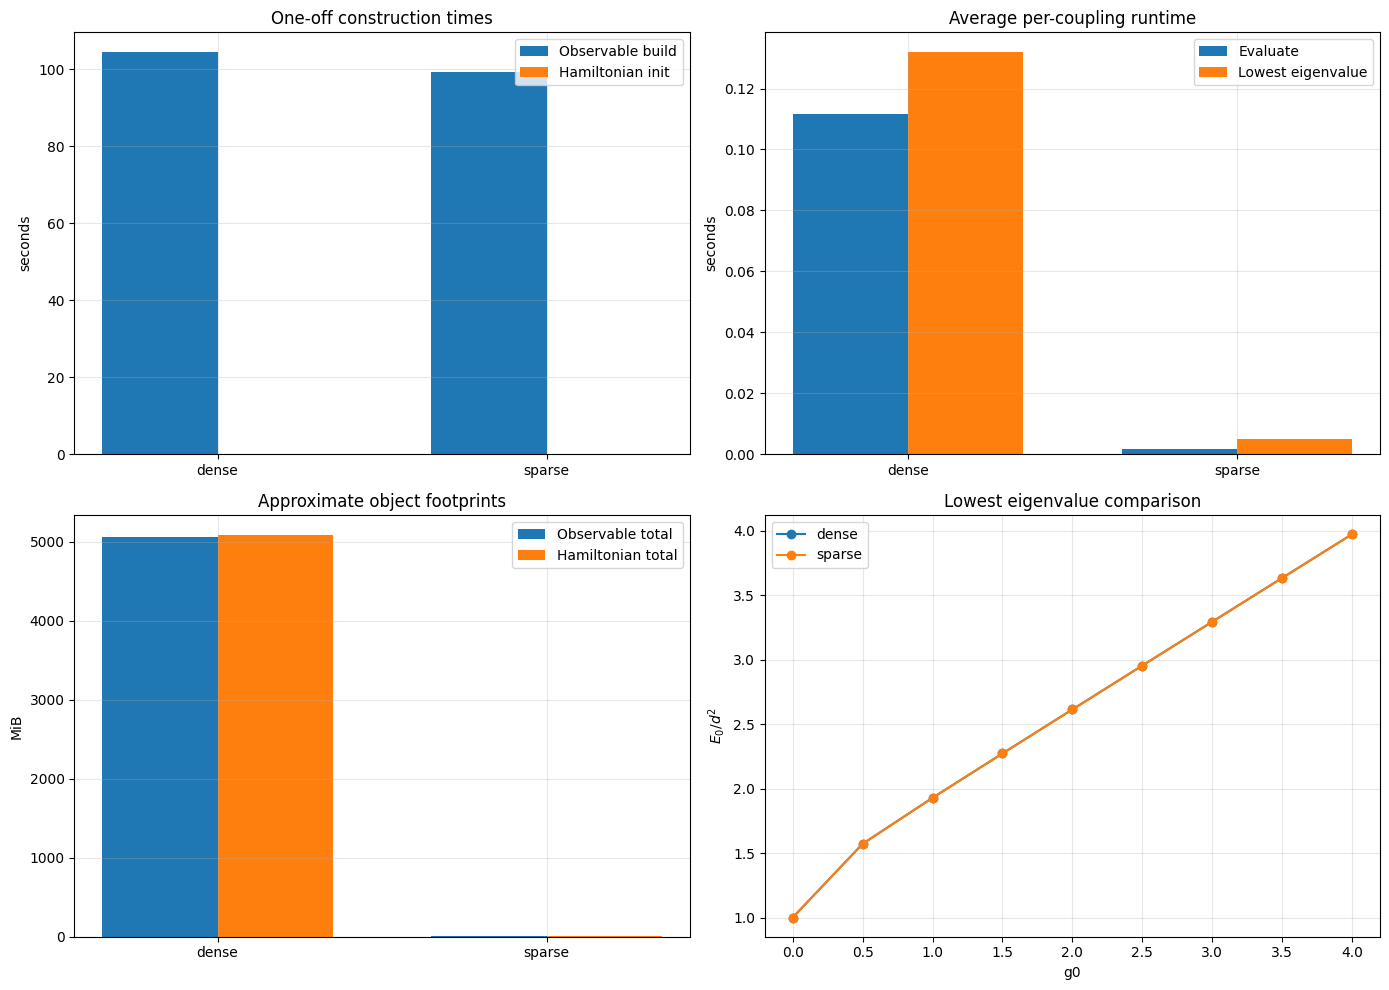

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

# Panel 1: one-off timings
x = np.arange(len(summary_df))
width = 0.35
axes[0].bar(
    x - width / 2,
    summary_df["observable_build_s"],
    width=width,
    label="Observable build",
)
axes[0].bar(
    x + width / 2,
    summary_df["hamiltonian_init_s"],
    width=width,
    label="Hamiltonian init",
)
axes[0].set_xticks(x, summary_df["storage"])
axes[0].set_ylabel("seconds")
axes[0].set_title("One-off construction times")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: average coupling-loop timings
axes[1].bar(x - width / 2, summary_df["avg_eval_s"], width=width, label="Evaluate")
axes[1].bar(
    x + width / 2, summary_df["avg_eig_s"], width=width, label="Lowest eigenvalue"
)
axes[1].set_xticks(x, summary_df["storage"])
axes[1].set_ylabel("seconds")
axes[1].set_title("Average per-coupling runtime")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: memory footprints
observable_total_mib = [
    result["observable_total_bytes"] / 1024**2 for result in results.values()
]
hamiltonian_total_mib = [
    result["hamiltonian_total_bytes"] / 1024**2 for result in results.values()
]
axes[2].bar(x - width / 2, observable_total_mib, width=width, label="Observable total")
axes[2].bar(
    x + width / 2, hamiltonian_total_mib, width=width, label="Hamiltonian total"
)
axes[2].set_xticks(x, summary_df["storage"])
axes[2].set_ylabel("MiB")
axes[2].set_title("Approximate object footprints")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Panel 4: first eigenvalue vs coupling
for storage, group in spectral_df.groupby("storage"):
    axes[3].plot(group["g0"], group["eig0_over_d2"], marker="o", label=storage)
axes[3].set_xlabel("g0")
axes[3].set_ylabel(r"$E_0 / d^2$")
axes[3].set_title("Lowest eigenvalue comparison")
axes[3].legend()
axes[3].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

In [9]:
comparison_df = summary_df.copy()
comparison_df["observable_total_bytes"] = [
    results[k]["observable_total_bytes"] for k in comparison_df["storage"]
]
comparison_df["hamiltonian_total_bytes"] = [
    results[k]["hamiltonian_total_bytes"] for k in comparison_df["storage"]
]
comparison_df["observable_coeff_bytes"] = [
    results[k]["observable_storage_bytes"] for k in comparison_df["storage"]
]
comparison_df

,storage,observable_build_s,hamiltonian_init_s,observable_coeff_storage,observable_total,hamiltonian_total,avg_eval_s,avg_eig_s,avg_total_s,observable_total_bytes,hamiltonian_total_bytes,observable_coeff_bytes
0,dense,104.425871,0.002664,2.47 GiB,4.94 GiB,4.97 GiB,0.111698,0.131851,0.243549,5303668551,5333788232,2651686560
1,sparse,99.219868,0.001487,13.53 MiB,13.81 MiB,14.38 MiB,0.001755,0.004926,0.006681,14481655,15079052,14183736


## Notes

- The observable footprint includes both metadata and coefficient storage; the Hamiltonian footprint additionally includes caches and references to the observable.
- Sparse matrices are compared using `scipy.sparse.linalg.eigsh`, while dense matrices use `numpy.linalg.eigvalsh`.
- If you want a stricter build-only comparison, clear any prerequisite data and rerun the setup cell so the woven/coset generation step happens explicitly before the timed sections.